In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("Impact_of_Remote_Work_Cleaned.csv")
df

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,...,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region,Virtual_Meetings_Flag
0,Emp0001,32,Non-binary,Hr,Healthcare,13,Hybrid,47,7,2,...,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe,0
1,Emp0002,40,Female,Data scientist,It,3,Remote,52,4,1,...,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia,0
2,Emp0003,59,Non-binary,Software engineer,Education,22,Hybrid,46,11,5,...,Anxiety,No,No change,4,Unsatisfied,5,Unknown,Poor,North america,0
3,Emp0004,27,Male,Software engineer,Finance,20,Onsite,32,8,4,...,Depression,Yes,Increase,3,Unsatisfied,3,Unknown,Poor,Europe,0
4,Emp0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,...,Unknown,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North america,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Emp4996,32,Male,Sales,Consulting,4,Onsite,24,2,5,...,Burnout,Yes,Decrease,4,Neutral,1,Weekly,Average,Asia,0
4996,Emp4997,39,Female,Sales,Healthcare,27,Onsite,48,15,1,...,Depression,Yes,Decrease,1,Satisfied,1,Unknown,Average,Africa,0
4997,Emp4998,42,Female,Sales,Healthcare,21,Hybrid,34,1,4,...,Burnout,No,Increase,3,Satisfied,1,Daily,Poor,Oceania,0
4998,Emp4999,27,Female,Sales,Healthcare,26,Remote,58,0,5,...,Unknown,Yes,Increase,3,Unsatisfied,4,Daily,Average,Asia,1


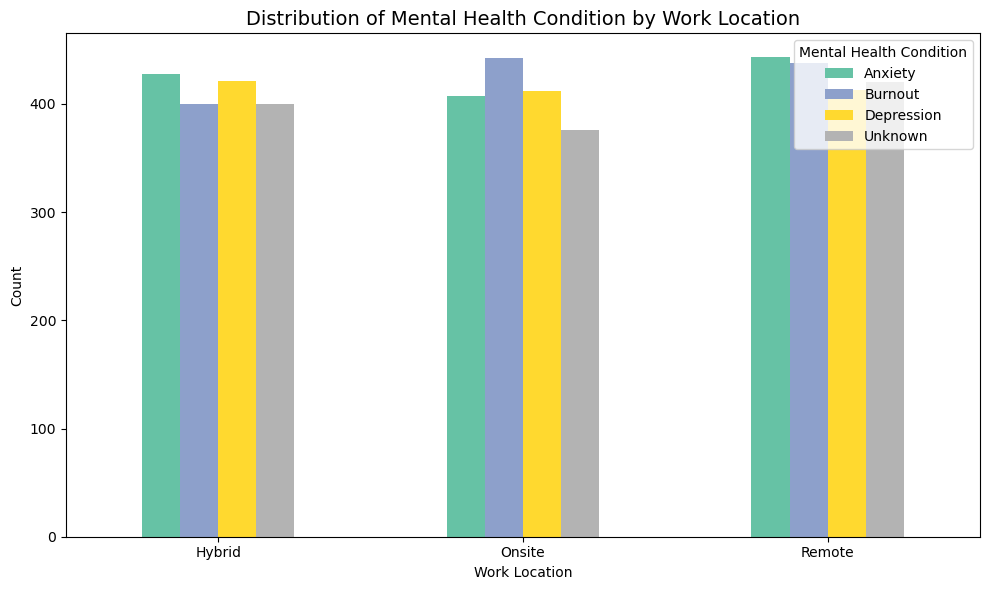

In [2]:
# 1. Grouped Bar Chart: Mental Health Condition by Work Location
import matplotlib.pyplot as plt
import pandas as pd

# Count frequencies of mental health conditions by work location
mh_counts = df.groupby('Work_Location')['Mental_Health_Condition'].value_counts().unstack().fillna(0)

# Plot grouped bar chart
mh_counts.plot(kind='bar', figsize=(10,6), colormap='Set2')
plt.title("Distribution of Mental Health Condition by Work Location", fontsize=14)
plt.xlabel("Work Location")
plt.ylabel("Count")
plt.legend(title="Mental Health Condition")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig("mental_health_by_work_location_histogram.png")
plt.close()

In [70]:
# 2. Descriptive Statistics: Work-Life Balance & Stress Level
# -------------------------------
wlb_stats = df.groupby('Work_Location')['Work_Life_Balance_Rating'].describe()
stress_stats = df.groupby('Work_Location')['Stress_Level'].describe()

print("📊 Work-Life Balance Rating by Work Location")
print(wlb_stats)
print("\n📊 Stress Level by Work Location")
stress_stats

📊 Work-Life Balance Rating by Work Location
                count      mean       std  min  25%  50%  75%  max
Work_Location                                                     
Hybrid         1649.0  3.022438  1.410813  1.0  2.0  3.0  4.0  5.0
Onsite         1637.0  2.946854  1.390321  1.0  2.0  3.0  4.0  5.0
Remote         1714.0  2.983081  1.429101  1.0  2.0  3.0  4.0  5.0

📊 Stress Level by Work Location


,count,unique,top,freq
Work_Location,,,,
Hybrid,1649,3,High,561
Onsite,1637,3,Low,555
Remote,1714,3,High,590


/tmp/ipykernel_28/2880555221.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=mean_ratings.index, y=mean_ratings.values, palette='pastel')


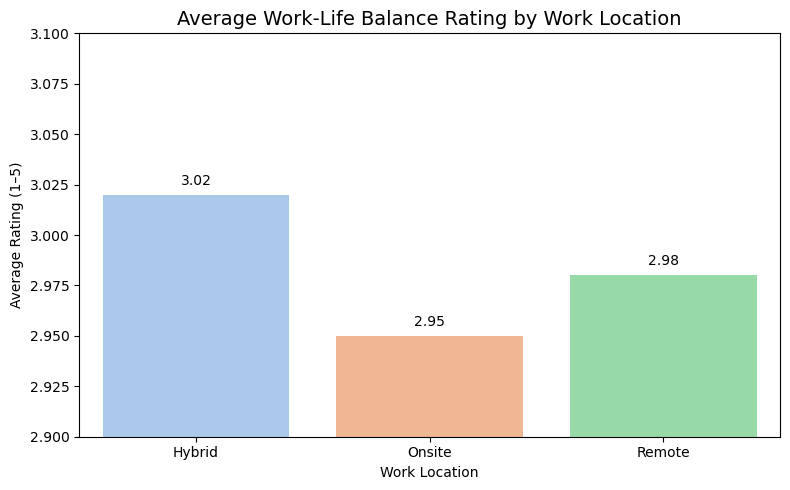

In [88]:
# 3. Bar Chart: Average Work-Life Balance Rating by Work Location
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("Impact_of_Remote_Work_Cleaned.csv")

# Standardize formatting
df['Work_Location'] = df['Work_Location'].str.strip().str.capitalize()

# Calculate mean ratings
mean_ratings = df.groupby('Work_Location')['Work_Life_Balance_Rating'].mean().round(2)

# Plot bar chart
plt.figure(figsize=(8, 5))
bars = sns.barplot(x=mean_ratings.index, y=mean_ratings.values, palette='pastel')

# Annotate each bar with its mean value
for bar, value in zip(bars.patches, mean_ratings.values):
    bars.annotate(f"{value}", 
                  xy=(bar.get_x() + bar.get_width() / 2, value), 
                  xytext=(0, 5), 
                  textcoords="offset points", 
                  ha='center', va='bottom', fontsize=10)

# Add titles and labels
plt.title("Average Work-Life Balance Rating by Work Location", fontsize=14)
plt.xlabel("Work Location")
plt.ylabel("Average Rating (1–5)")
plt.ylim(2.9, 3.1)  # Optional: narrow y-axis to emphasize differences
plt.tight_layout()

# Save chart
plt.show()
plt.savefig("work_life_balance_mean_barchart.png")
plt.close()


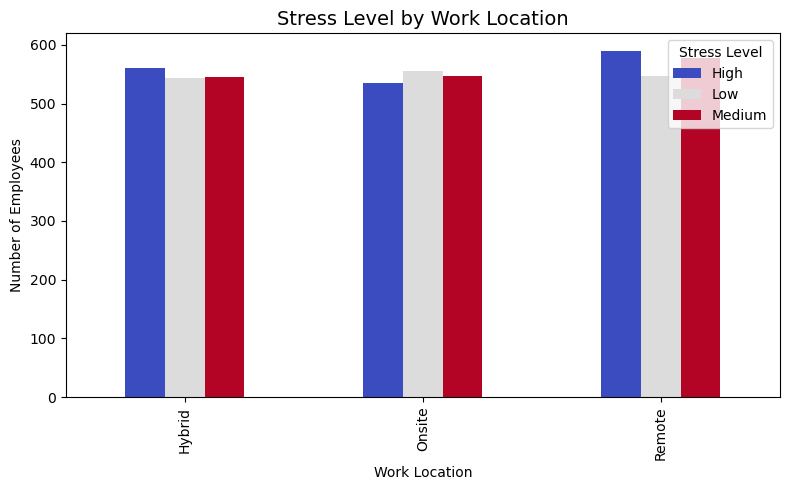

In [1]:
# 4. Grouped Bar Chart: Stress Level by Work Location
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("Impact_of_Remote_Work_Cleaned.csv")

# Standardize formatting
df['Stress_Level'] = df['Stress_Level'].str.strip().str.capitalize()
df['Work_Location'] = df['Work_Location'].str.strip().str.capitalize()

# Create frequency table
stress_counts = df.groupby('Work_Location')['Stress_Level'].value_counts().unstack().fillna(0)

# Plot grouped bar chart
stress_counts.plot(kind='bar', figsize=(8, 5), colormap='coolwarm')
plt.title("Stress Level by Work Location", fontsize=14)
plt.xlabel("Work Location")
plt.ylabel("Number of Employees")
plt.legend(title="Stress Level")
plt.tight_layout()

# Save chart
plt.show()
plt.savefig("stress_level_grouped_barchart.png")
plt.close()
